## EPMT Play

We're trying to query EPMT Data into a simple csv file. The focus of this notebook is the EPMT_JOB_TAGS annotations for now, but the data will eventually be expanded. A little bit of visualization is also added. Finally, a really quick and dirty ML Linear Regression attempt is at the end.

In [1]:
# Environment work around to get matplotlib/seaborn
import sys
sys.path.append('/home/Janice.Kim/work/epmt/misc/jk_py37')

In [2]:
import epmt_query as eq

In [3]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import csv
import pandas as pd
from pprint import pprint

In [4]:
def parse_annotations(annotations: str):
    """"                                                                                                                                                                                                           
    Returns dict parsed from the annotations string                                                                                                                                                                
    """
    result = {}
    for pair in annotations.split(";"):
        key, val = pair.split(":", 1) # Take the first colon. Assumption: There shouldn't be more than one.                                                                                                        
        result[key.strip()] = val.strip()
    return result

In [5]:
all_jobs = eq.get_jobs(fmt='dict', limit=1000) # TODO: increase limit once things look okay.                                                                                                                     
data = []
for job in all_jobs:
    row = parse_annotations(job['annotations']['EPMT_JOB_TAGS'])
    row['cpu_time'] = job['cpu_time']
    data.append(row)

print(f"Writing {len(data)} rows.")
labels = data[0].keys()

Writing 1000 rows.


Ask Ian or Avery: Is it normal to expect the EPMT_JOB_TAGS to have different keys for each for? Sometimes the labels are different depending on which rows I'm looking at. 

In [6]:
#for d in data:
#    pprint(d)

In [7]:
with open("/home/Janice.Kim/work/epmt/jk_data_play.csv", "w") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=labels)
    writer.writeheader()
    writer.writerows(data)

## Look at the Data and Visualize a Bit

Now, let's see what we have and try to visualize a little of the data.

In [8]:
csv_path = "/home/Janice.Kim/work/epmt/jk_data_play.csv"
target_col = "cpu_time" # ground truth column

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:\n", df.dtypes)

Shape: (1000, 9)
Columns:
 exp_component      object
exp_fre_mod        object
exp_name           object
exp_time            int64
exp_platform       object
exp_target         object
exp_seg_months      int64
script_name        object
cpu_time          float64
dtype: object


In [9]:
df.head()

,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name,cpu_time
0,river_cubic,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_river_cubic...,103951272.0
1,atmos_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_atmos_scala...,12713067.0
2,ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_ocean_scala...,22186898.0
3,ocean_daily_1deg,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_ocean_daily...,5032113.0
4,ice_1deg,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_ice_1deg_00...,72152950.0


In [10]:
df.describe()

,exp_time,exp_seg_months,cpu_time
count,1.000000e+03,1000.0,1.000000e+03
mean,1.630640e+07,12.0,6.101542e+07
std,7.272185e+06,0.0,4.944633e+07
min,2.801010e+05,12.0,2.668559e+06
25%,1.978010e+07,12.0,2.302122e+07
50%,2.026010e+07,12.0,4.969014e+07
75%,2.026010e+07,12.0,8.659378e+07
max,2.026010e+07,12.0,3.363880e+08


In [11]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
category_cols = df.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

# numeric columns: 3
# category columns: 6


Text(0.5, 0.98, 'Numeric Feature Distributions')

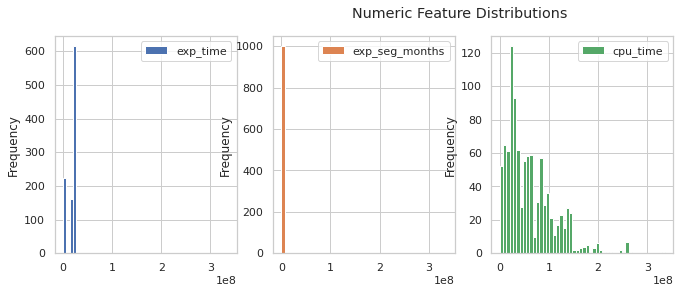

In [56]:
df["cpu_bin"] = pd.qcut(df["cpu_time"], q=3, labels=[0, 1, 2])
numeric_cols.append("cpu_bin")

axes = df[numeric_cols].plot(kind='hist', bins=50, subplots=True, layout=(1,4), figsize=(15,4))
plt.suptitle("Numeric Feature Distributions")

In [59]:
df[numeric_cols].head()

,exp_time,exp_seg_months,cpu_time,cpu_bin
0,1000101,12,103951272.0,2
1,1000101,12,12713067.0,0
2,990101,12,22186898.0,0
3,990101,12,5032113.0,0
4,990101,12,72152950.0,1


In [64]:
df.select_dtypes(include="number").columns.tolist()
print("Columns:\n", df.dtypes)
bins, edges = pd.qcut(df["cpu_time"], q=3, retbins=True)

for i, label in enumerate([0, 1, 2]):
    print(f"{label}: [{edges[i]:.3f}, {edges[i+1]:.3f})")

Columns:
 exp_component       object
exp_fre_mod         object
exp_name            object
exp_time             int64
exp_platform        object
exp_target          object
exp_seg_months       int64
script_name         object
cpu_time           float64
cpu_bin           category
dtype: object
0: [2668559.000, 29223324.000)
1: [29223324.000, 73752163.000)
2: [73752163.000, 336387964.000)


## One-hot Encoding the Categorical Columns

In [13]:
from sklearn.preprocessing import OneHotEncoder

print("Category Columns:", category_cols)
df[category_cols].head()

Category Columns: ['exp_component', 'exp_fre_mod', 'exp_name', 'exp_platform', 'exp_target', 'script_name']


,exp_component,exp_fre_mod,exp_name,exp_platform,exp_target,script_name
0,river_cubic,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_river_cubic...
1,atmos_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_atmos_scala...
2,ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_scala...
3,ocean_daily_1deg,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ocean_daily...
4,ice_1deg,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Control_1990_A13_ice_1deg_00...


In [14]:
category_cols_mod = ['exp_fre_mod', 'exp_platform', 'exp_target'] # exp_component, removing 'exp_name', 'script_name'
ohe = OneHotEncoder(sparse=False)
ohe_data = ohe.fit_transform(df[category_cols_mod])
ohe_cols = ohe.get_feature_names(category_cols_mod)
df_categorical = pd.DataFrame(ohe_data, columns=ohe_cols)
df_categorical.head()

,exp_fre_mod_/home/fms/local/opt/fre-commands/bronx-23,exp_platform_gfdl.ncrc5-intel23,exp_platform_gfdl.ncrc5-intel23-classic,exp_platform_gfdl.ncrc5-intel23_2_0,exp_platform_gfdl.ncrc6-intel23,exp_platform_gfdl.ncrc6-intel23-classic,exp_target_prod,exp_target_prod-openmp,exp_target_repro,exp_target_repro-openmp
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


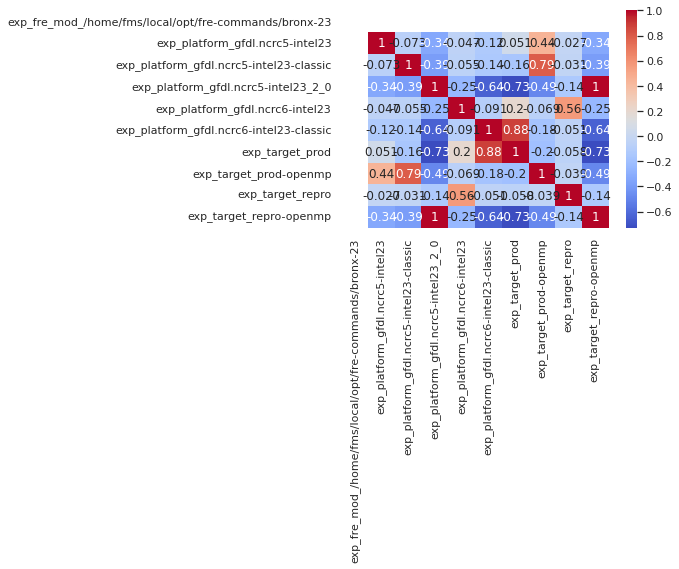

In [26]:
corr = df_categorical[ohe_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

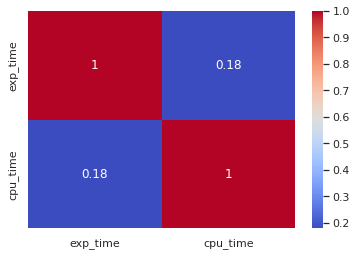

In [31]:
sns.heatmap(df[['exp_time', 'cpu_time']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
def plot_one_category(df_categorical, single_category):
    startswith = f"{single_category}_"
    cols = [c for c in df_categorical.columns if c.startswith(startswith)]
    df_categorical[cols].sum().plot(kind='bar', figsize=(15,5))
    plt.ylabel('Count')
    plt.show()
    
#plot_one_category(df_categorical, "exp_component")

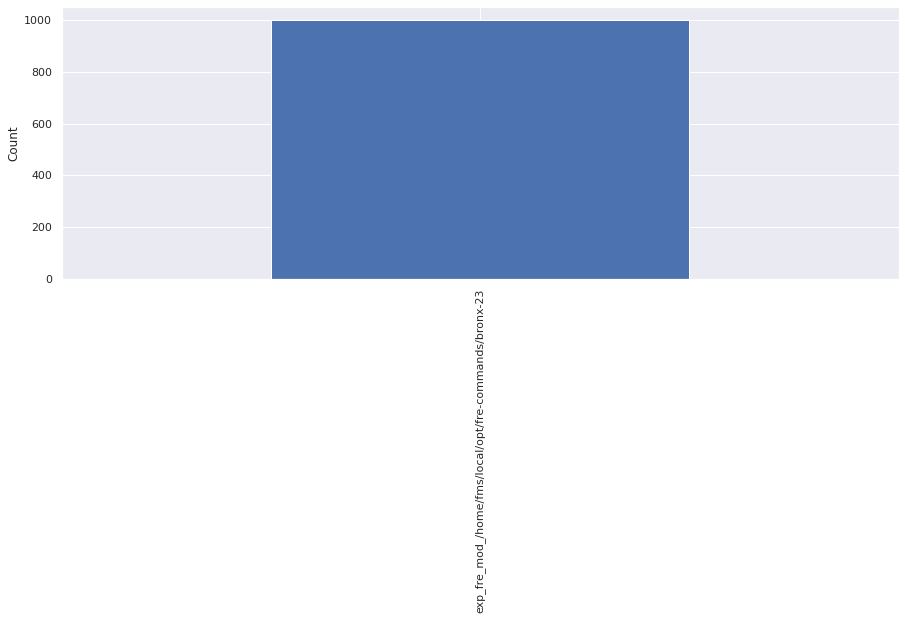

In [17]:
plot_one_category(df_categorical, "exp_fre_mod")

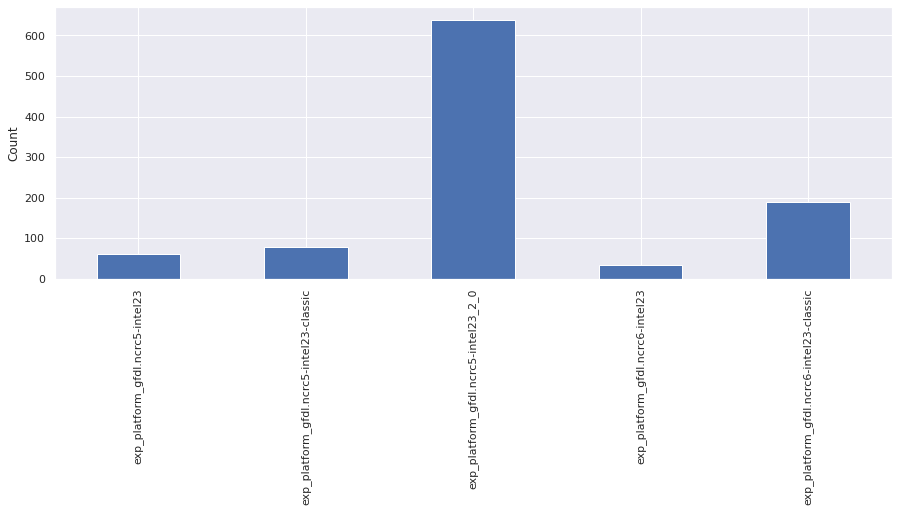

In [18]:
plot_one_category(df_categorical, "exp_platform")

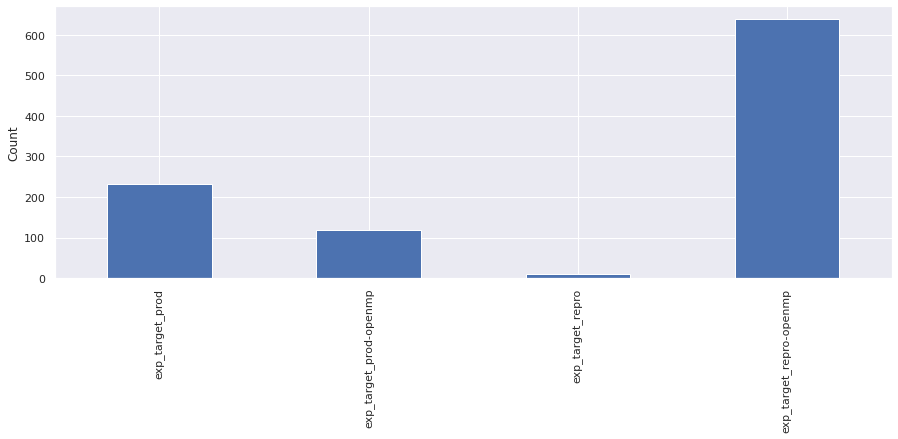

In [19]:
plot_one_category(df_categorical, "exp_target")

## Put the Numerical and Categorical Data Together
Combine subset of one-hot encoded categorical data with numerical data.

In [69]:
df_full = pd.concat(
    [df[numeric_cols], df_categorical],
    axis=1
)
df_full.head()

,exp_time,exp_seg_months,cpu_time,cpu_bin,exp_fre_mod_/home/fms/local/opt/fre-commands/bronx-23,exp_platform_gfdl.ncrc5-intel23,exp_platform_gfdl.ncrc5-intel23-classic,exp_platform_gfdl.ncrc5-intel23_2_0,exp_platform_gfdl.ncrc6-intel23,exp_platform_gfdl.ncrc6-intel23-classic,exp_target_prod,exp_target_prod-openmp,exp_target_repro,exp_target_repro-openmp
0,1000101,12,103951272.0,2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1000101,12,12713067.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,990101,12,22186898.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,990101,12,5032113.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,990101,12,72152950.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## Split up Training and Testing Sets

Some useful links:
* https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
* https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.metrics import accuracy_score, classification_report

In [70]:
target = 'cpu_time'

#X = df_full.drop(target, axis=1)
X = df_full.drop(columns=['exp_time', 'cpu_time', 'cpu_bin'], axis=1)
y = df_full[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

## Basic Training - Linear Regression with 'cpu_time' as the Target

In [94]:

target = 'cpu_bin'
X = df_full.drop(columns=['exp_time', 'cpu_time', 'cpu_bin'], axis=1)
y = df_full[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

model_logreg = LogisticRegression(max_iter=500)
model_logreg.fit(X_train, y_train)

y_pred = model_logreg.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.61      0.26      0.36       166
           1       0.44      0.29      0.35       151
           2       0.42      0.75      0.54       183

    accuracy                           0.45       500
   macro avg       0.49      0.43      0.42       500
weighted avg       0.49      0.45      0.42       500



In [72]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 2426295927920982.00
R-squared Score: 0.06


## Visualizing the Results (Thanks Gemini for this part!)

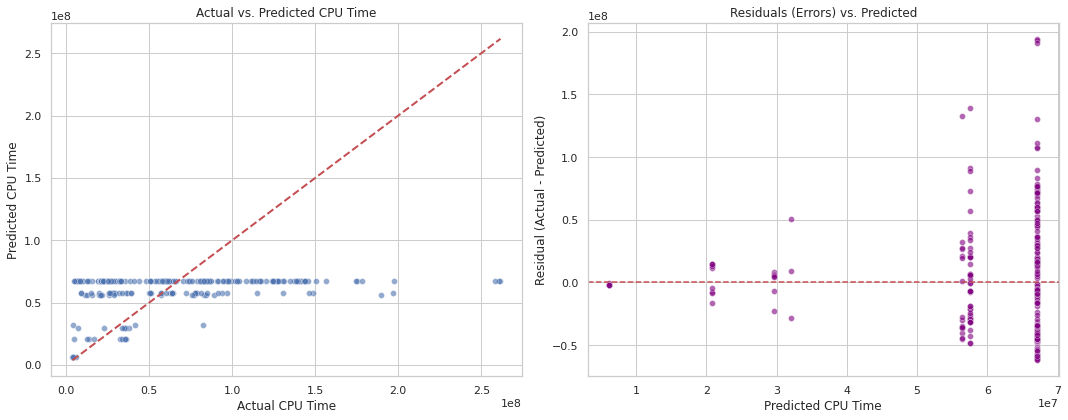

In [25]:
# TODO Code for the following was generated by Gemini. It will be inspected more carefully

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Actual vs Predicted ---
sns.scatterplot(x=y_test, y=predictions, ax=ax1, alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
ax1.set_title('Actual vs. Predicted CPU Time')
ax1.set_xlabel('Actual CPU Time')
ax1.set_ylabel('Predicted CPU Time')

# --- Plot 2: Residual Plot ---
residuals = y_test - predictions
sns.scatterplot(x=predictions, y=residuals, ax=ax2, color='purple', alpha=0.6)
ax2.axhline(y=0, color='r', linestyle='--') # Zero-error line
ax2.set_title('Residuals (Errors) vs. Predicted')
ax2.set_xlabel('Predicted CPU Time')
ax2.set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()